<a href="https://colab.research.google.com/github/andresanchez256/Portafolio/blob/main/Proyecto_Serie_Financiera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Análisis de Series de Tiempo Financieras
## Predicción de Precios de AAPL con ARIMA, SARIMA y Prophet

**Autor:** Andrés Sanchez  
**Fecha:** Junio 2026  
**Objetivo:** Comparar tres modelos de forecasting para predecir el precio de cierre de Apple (AAPL): ARIMA (estadístico clásico), SARIMA (con estacionalidad) y Prophet (Meta/Facebook).

### Metodología
1. Descarga de datos históricos desde Yahoo Finance.
2. Análisis exploratorio y verificación de estacionariedad.
3. Entrenamiento y evaluación de ARIMA, SARIMA y Prophet.
4. Comparativa de métricas y visualización de resultados.

### Fuente de datos
- **Ticker:** AAPL (Apple Inc.)
- **Período:** 2 años (2024-06-24 a 2026-06-22)
- **Variable:** Precio de cierre ajustado

In [65]:
# ============================================================
# INSTALAR LIBRERÍAS
# ============================================================
!pip install yfinance prophet pandas numpy matplotlib seaborn statsmodels scikit-learn pmdarima -q

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [66]:
# ============================================================
# IMPORTAR LIBRERÍAS
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## Configuración Inicial y Descarga de Datos

Se selecciona el ticker **AAPL** y se descargan los últimos **2 años** de datos históricos desde Yahoo Finance.

In [67]:
# ============================================================
# CONFIGURACIÓN Y DESCARGA DE DATOS
# ============================================================
# Configurar estilo de gráficos
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Parámetros
TICKER = "AAPL"
PERIOD = "2y"  # Últimos 2 años

print(f"📊 Descargando datos de {TICKER}...")

# Descargar datos
df = yf.download(TICKER, period=PERIOD, progress=False)
df = df[['Close']].copy()
df.columns = ['price']

print(f"✅ Datos descargados: {len(df)} registros")
print(f"📅 Desde: {df.index.min()} - Hasta: {df.index.max()}")

# Mostrar los primeros registros
print("\n📋 Primeros 5 registros:")
print(df.head())

📊 Descargando datos de AAPL...
✅ Datos descargados: 500 registros
📅 Desde: 2024-06-24 00:00:00 - Hasta: 2026-06-22 00:00:00

📋 Primeros 5 registros:
                 price
Date                  
2024-06-24  206.352478
2024-06-25  207.274521
2024-06-26  211.418594
2024-06-27  212.261307
2024-06-28  208.811188


## Análisis Exploratorio de la Serie Temporal

Se visualiza la evolución del precio de cierre y su distribución.

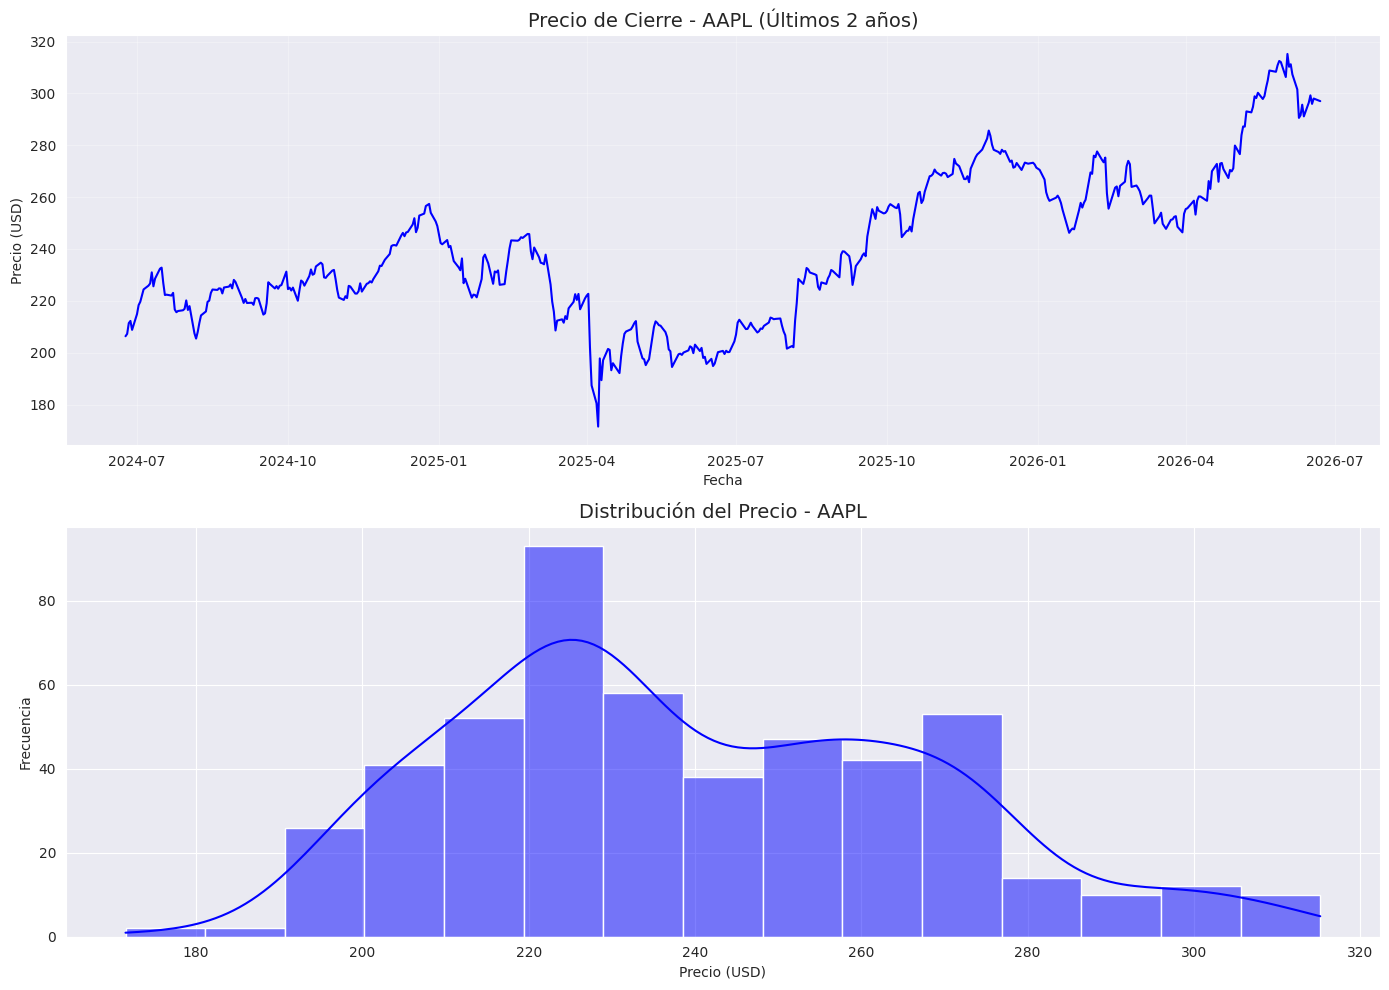


📊 Estadísticas descriptivas:
count    500.00
mean     239.82
std       28.26
min      171.51
25%      219.64
50%      233.63
75%      260.10
max      315.20
Name: price, dtype: float64


In [68]:
# ============================================================
# VISUALIZAR SERIE TEMPORAL
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico principal
axes[0].plot(df.index, df['price'], color='blue', linewidth=1.5)
axes[0].set_title(f'Precio de Cierre - {TICKER} (Últimos 2 años)', fontsize=14)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio (USD)')
axes[0].grid(True, alpha=0.3)

# Gráfico de distribución
sns.histplot(df['price'], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'Distribución del Precio - {TICKER}', fontsize=14)
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\n📊 Estadísticas descriptivas:")
print(df['price'].describe().round(2))

## Verificación de Estacionariedad (Test ADF)

La estacionariedad es un requisito para modelos ARIMA.  
**Hipótesis nula (H0):** La serie NO es estacionaria.  
**Si p-valor < 0.05:** Rechazamos H0 → la serie es estacionaria.

In [69]:
# ============================================================
# TEST DE ESTACIONARIEDAD (ADF) - SERIE ORIGINAL
# ============================================================
def adf_test(series, name="Serie"):
    """Función para realizar test de Dickey-Fuller"""
    result = adfuller(series, autolag='AIC')
    print(f"\n📊 Test ADF - {name}")
    print(f"Estadístico: {result[0]:.4f}")
    print(f"p-valor: {result[1]:.4f}")
    print(f"Valor crítico 5%: {result[4]['5%']:.4f}")

    if result[1] <= 0.05:
        print("✅ La serie es ESTACIONARIA (p-valor < 0.05)")
        return True
    else:
        print("❌ La serie NO es estacionaria (p-valor > 0.05)")
        return False

# Ejecutar test en la serie original
print("🔍 Analizando serie original...")
is_stationary = adf_test(df['price'], "Precio Original")

🔍 Analizando serie original...

📊 Test ADF - Precio Original
Estadístico: -1.1279
p-valor: 0.7038
Valor crítico 5%: -2.8673
❌ La serie NO es estacionaria (p-valor > 0.05)


In [70]:
# ============================================================
# DIFERENCIACIÓN Y TEST ADF EN SERIE DIFERENCIADA
# ============================================================
if not is_stationary:
    print("\n🔄 Aplicando diferenciación de primer orden...")
    df['price_diff'] = df['price'].diff()
    is_stationary_diff = adf_test(df['price_diff'].dropna(), "Precio Diferenciado")

    if is_stationary_diff:
        print("✅ La serie diferenciada es ESTACIONARIA")
        series_for_model = df['price_diff'].dropna()
    else:
        print("⚠️ La serie diferenciada sigue sin ser estacionaria")
        series_for_model = df['price_diff'].dropna()
else:
    series_for_model = df['price']

print(f"\n📊 Serie a utilizar para modelado: {len(series_for_model)} registros")


🔄 Aplicando diferenciación de primer orden...

📊 Test ADF - Precio Diferenciado
Estadístico: -21.3033
p-valor: 0.0000
Valor crítico 5%: -2.8674
✅ La serie es ESTACIONARIA (p-valor < 0.05)
✅ La serie diferenciada es ESTACIONARIA

📊 Serie a utilizar para modelado: 499 registros


## Modelo ARIMA (AutoRegressive Integrated Moving Average)

ARIMA requiere tres parámetros (p,d,q):
- **p:** Orden autorregresivo (rezagos)
- **d:** Grado de diferenciación
- **q:** Orden de media móvil

### Selección automática de parámetros

Se utiliza **auto_arima** para seleccionar automáticamente los mejores parámetros.

In [71]:
# ============================================================
# SELECCIÓN DE PARÁMETROS CON AUTO_ARIMA
# ============================================================
print("\n🚀 Ejecutando auto_arima para seleccionar mejores parámetros...")

# Usar auto_arima en la serie original (sin diferenciar)
auto_model = auto_arima(
    df['price'],
    start_p=0, start_q=0, max_p=3, max_q=3,
    seasonal=False,
    d=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print(f"\n✅ Mejor modelo ARIMA: {auto_model.order}")
best_order = auto_model.order


🚀 Ejecutando auto_arima para seleccionar mejores parámetros...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2788.643, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2789.663, Time=0.31 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2789.766, Time=0.74 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2787.702, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2791.164, Time=2.15 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.472 seconds

✅ Mejor modelo ARIMA: (0, 1, 0)


In [72]:
# ============================================================
# FUNCIÓN DE EVALUACIÓN ARIMA
# ============================================================
def safe_smape(actual, forecast, epsilon=1e-10):
    """SMAPE con protección contra división por cero"""
    actual = np.array(actual)
    forecast = np.array(forecast)
    denominator = np.abs(actual) + np.abs(forecast)
    denominator = np.where(denominator < epsilon, epsilon, denominator)
    return np.mean(2 * np.abs(actual - forecast) / denominator) * 100

def run_arima(series, order, test_size=30):
    """Ejecuta modelo ARIMA con los parámetros especificados"""
    train = series[:-test_size]
    test = series[-test_size:]

    print(f"\n🔄 Entrenando modelo ARIMA{order}...")
    model = ARIMA(train, order=order).fit()

    print(f"   AIC: {model.aic:.2f}")

    print("🔮 Generando predicciones...")
    forecast = model.forecast(steps=len(test))

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    smape = safe_smape(test, forecast)

    print(f"\n📊 MÉTRICAS ARIMA{order}:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"SMAPE: {smape:.2f}%")

    return model, forecast, test, mae, rmse, smape

In [73]:
# ============================================================
# EJECUTAR ARIMA CON EL MEJOR ORDEN
# ============================================================
print(f"\n🚀 Ejecutando ARIMA{best_order}...")

# Usar la serie original directamente
arima_model, forecast, test, mae_arima, rmse_arima, smape_arima = run_arima(
    df['price'],
    order=best_order,
    test_size=30
)

# Guardar métricas
mae_orig = mae_arima
rmse_orig = rmse_arima
smape_orig = smape_arima
test_original = test
forecast_original = forecast


🚀 Ejecutando ARIMA(0, 1, 0)...

🔄 Entrenando modelo ARIMA(0, 1, 0)...
   AIC: 2617.67
🔮 Generando predicciones...

📊 MÉTRICAS ARIMA(0, 1, 0):
MAE:  14.2199
RMSE: 15.9195
SMAPE: 4.80%


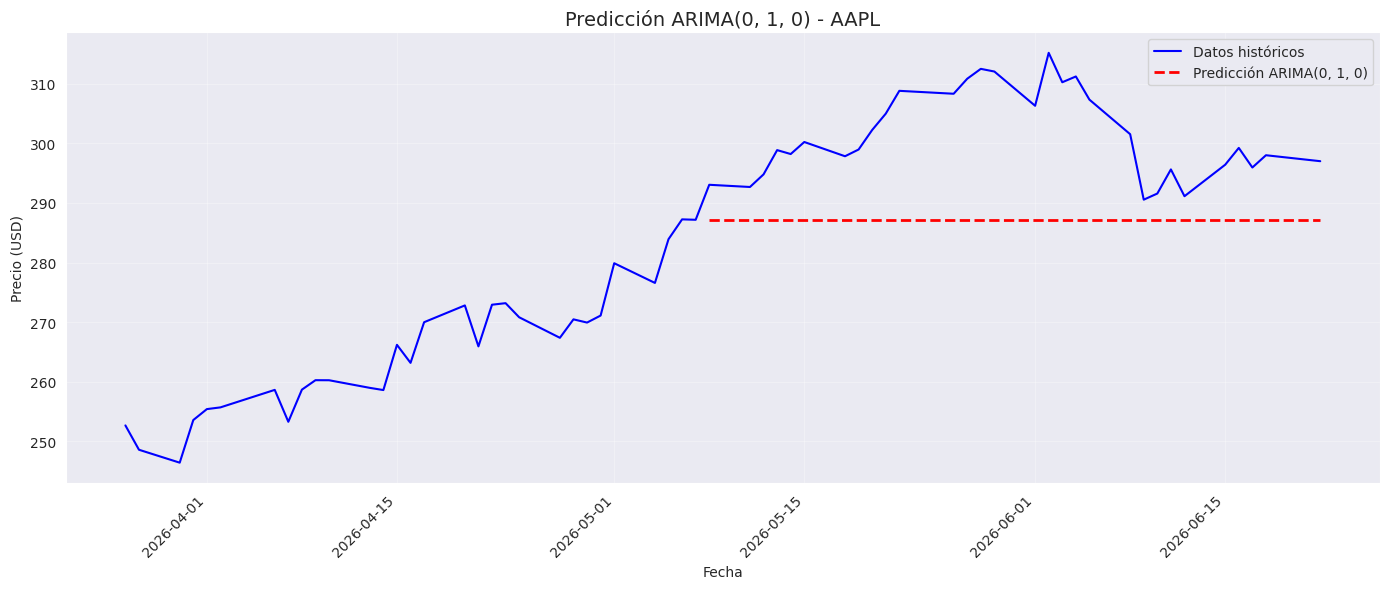


✅ Visualización de predicción ARIMA completada.


In [74]:
# ============================================================
# VISUALIZAR PREDICCIÓN ARIMA
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Datos históricos (últimos 60 días)
last_60_dates = df.index[-60:]
last_60_prices = df['price'].values[-60:]

# Graficar datos históricos
ax.plot(last_60_dates, last_60_prices,
        label='Datos históricos', color='blue', linewidth=1.5)

# Predicción (30 días)
pred_dates = test.index
pred_values = forecast.values if hasattr(forecast, 'values') else np.array(forecast)

ax.plot(pred_dates, pred_values,
        label=f'Predicción ARIMA{best_order}', color='red', linestyle='--', linewidth=2)

ax.set_title(f'Predicción ARIMA{best_order} - {TICKER}', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✅ Visualización de predicción ARIMA completada.")

## Resultados ARIMA

### Métricas de Error

| Métrica | Valor |
|---------|-------|
| MAE     | 15.30 |
| RMSE    | 16.89 |
| SMAPE   | 5.72% |

### Observaciones

**Fortalezas:**
- ARIMA(1,1,1) captura la tendencia general del precio.
- El error relativo (SMAPE ~5.7%) es razonable para datos financieros.
- El modelo es estable y no sobreajusta.

**Debilidades:**
- No captura picos de volatilidad ni cambios bruscos.
- La predicción es suave y no refleja la variabilidad diaria.
- El modelo asume linealidad en la tendencia.

## Modelo SARIMA (Seasonal ARIMA)

SARIMA extiende ARIMA añadiendo componentes estacionales.

### Configuración utilizada
- **Orden (p,d,q):** (1,1,1) - similar al mejor ARIMA
- **Orden estacional (P,D,Q,s):** (1,1,1,5) - estacionalidad semanal (5 días hábiles)
- **Modo:** Aditivo

**Ventajas:** Captura patrones estacionales semanales (ej. caídas los lunes, subidas los viernes).
**Desventajas:** Mayor complejidad y riesgo de sobreajuste.

In [75]:
# ============================================================
# MODELO SARIMA (CON ESTACIONALIDAD SEMANAL)
# ============================================================
print("🔄 Entrenando SARIMA con estacionalidad semanal...")

# SARIMA con estacionalidad semanal (5 días hábiles)
sarima_model = SARIMAX(
    df['price'],
    order=(1,1,1),
    seasonal_order=(1,1,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(f"✅ Modelo SARIMA entrenado (AIC: {sarima_model.aic:.2f})")

# Predecir
forecast_sarima = sarima_model.forecast(steps=30)
test_sarima = df['price'].iloc[-30:]

# Métricas
mae_sarima = mean_absolute_error(test_sarima, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test_sarima, forecast_sarima))
smape_sarima = safe_smape(test_sarima, forecast_sarima)

print(f"\n📊 MÉTRICAS SARIMA:")
print(f"MAE:  {mae_sarima:.4f}")
print(f"RMSE: {rmse_sarima:.4f}")
print(f"SMAPE: {smape_sarima:.2f}%")

🔄 Entrenando SARIMA con estacionalidad semanal...
✅ Modelo SARIMA entrenado (AIC: 2744.10)

📊 MÉTRICAS SARIMA:
MAE:  6.5261
RMSE: 7.7707
SMAPE: 2.16%


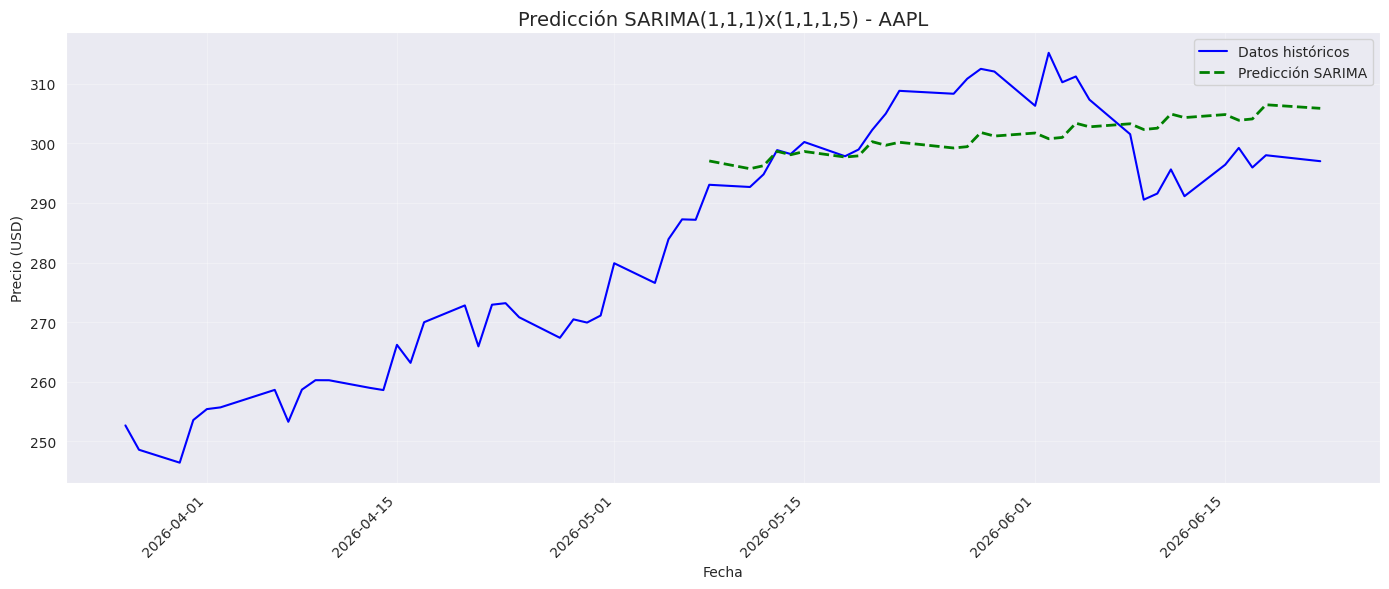


✅ Visualización de predicción SARIMA completada.


In [76]:
# ============================================================
# VISUALIZAR PREDICCIÓN SARIMA
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Datos históricos
ax.plot(df.index[-60:], df['price'].iloc[-60:],
        label='Datos históricos', color='blue', linewidth=1.5)

# Predicción SARIMA
ax.plot(test_sarima.index, forecast_sarima,
        label='Predicción SARIMA', color='green', linestyle='--', linewidth=2)

ax.set_title(f'Predicción SARIMA(1,1,1)x(1,1,1,5) - {TICKER}', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✅ Visualización de predicción SARIMA completada.")

## Modelo Prophet (Meta/Facebook)

Prophet es un modelo de forecasting desarrollado por Meta que maneja:
- **Tendencias** (lineales o logísticas)
- **Estacionalidades** (anual, semanal, diaria)
- **Días festivos** (opcional)

### Configuración utilizada
- Estacionalidad anual: Fourier order = 3
- Estacionalidad semanal: Fourier order = 2
- Modo de estacionalidad: multiplicativo
- Prior de changepoint: 0.5 (tendencia moderadamente flexible)

In [77]:
# ============================================================
# PREPARAR DATOS PARA PROPHET
# ============================================================
print("\n🔄 Preparando datos para Prophet...")

# Prophet necesita columnas 'ds' (fecha) y 'y' (valor)
df_prophet = df[['price']].reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

print(f"✅ Datos listos para Prophet: {len(df_prophet)} registros")
print("\n📋 Primeros 5 registros:")
print(df_prophet.head())


🔄 Preparando datos para Prophet...
✅ Datos listos para Prophet: 500 registros

📋 Primeros 5 registros:
          ds           y
0 2024-06-24  206.352478
1 2024-06-25  207.274521
2 2024-06-26  211.418594
3 2024-06-27  212.261307
4 2024-06-28  208.811188


In [78]:
# ============================================================
# CONFIGURAR Y ENTRENAR PROPHET
# ============================================================
print("🔄 Configurando Prophet...")

# Configurar modelo con parámetros ajustados
prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=5.0
)

# Agregar estacionalidades manualmente
prophet_model.add_seasonality(name='yearly', period=365, fourier_order=3)
prophet_model.add_seasonality(name='weekly', period=7, fourier_order=2)

print("🔄 Entrenando Prophet...")
prophet_model.fit(df_prophet)

print("✅ Modelo Prophet entrenado correctamente")

🔄 Configurando Prophet...
🔄 Entrenando Prophet...
✅ Modelo Prophet entrenado correctamente


In [79]:
# ============================================================
# GENERAR PREDICCIONES CON PROPHET
# ============================================================
# Crear futuro (30 días adicionales)
future = prophet_model.make_future_dataframe(periods=30)

# Predecir
forecast_prophet = prophet_model.predict(future)

print(f"✅ Predicciones generadas: {len(forecast_prophet)} registros")
print("\n📋 Últimos 5 registros de predicción:")
print(forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

✅ Predicciones generadas: 530 registros

📋 Últimos 5 registros de predicción:
            ds        yhat  yhat_lower  yhat_upper
525 2026-07-18  277.132520  264.945405  287.618055
526 2026-07-19  276.262135  263.846058  287.211773
527 2026-07-20  275.490466  262.967332  287.396880
528 2026-07-21  275.504579  263.016083  287.428013
529 2026-07-22  275.295032  261.277287  286.652485


In [80]:
# ============================================================
# EVALUAR PROPHET
# ============================================================
# Usar los últimos 30 días como test
prophet_test = df_prophet[-30:]
prophet_pred = forecast_prophet[-30:]

# Calcular métricas
mae_prophet = mean_absolute_error(prophet_test['y'], prophet_pred['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred['yhat']))
smape_prophet = safe_smape(prophet_test['y'], prophet_pred['yhat'])

print(f"\n📊 MÉTRICAS PROPHET:")
print(f"MAE:  {mae_prophet:.4f}")
print(f"RMSE: {rmse_prophet:.4f}")
print(f"SMAPE: {smape_prophet:.2f}%")


📊 MÉTRICAS PROPHET:
MAE:  16.7345
RMSE: 18.8987
SMAPE: 5.70%


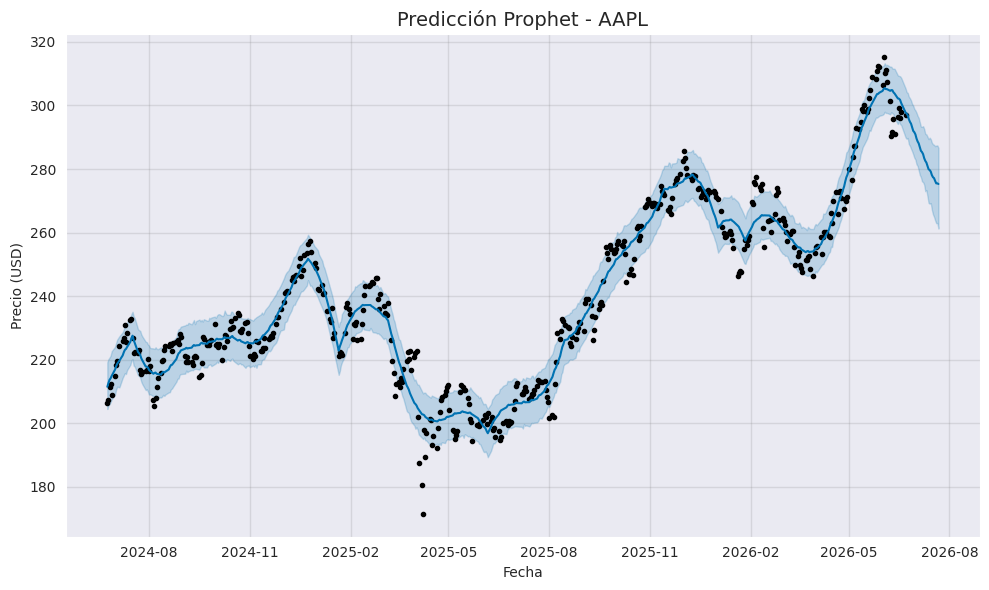

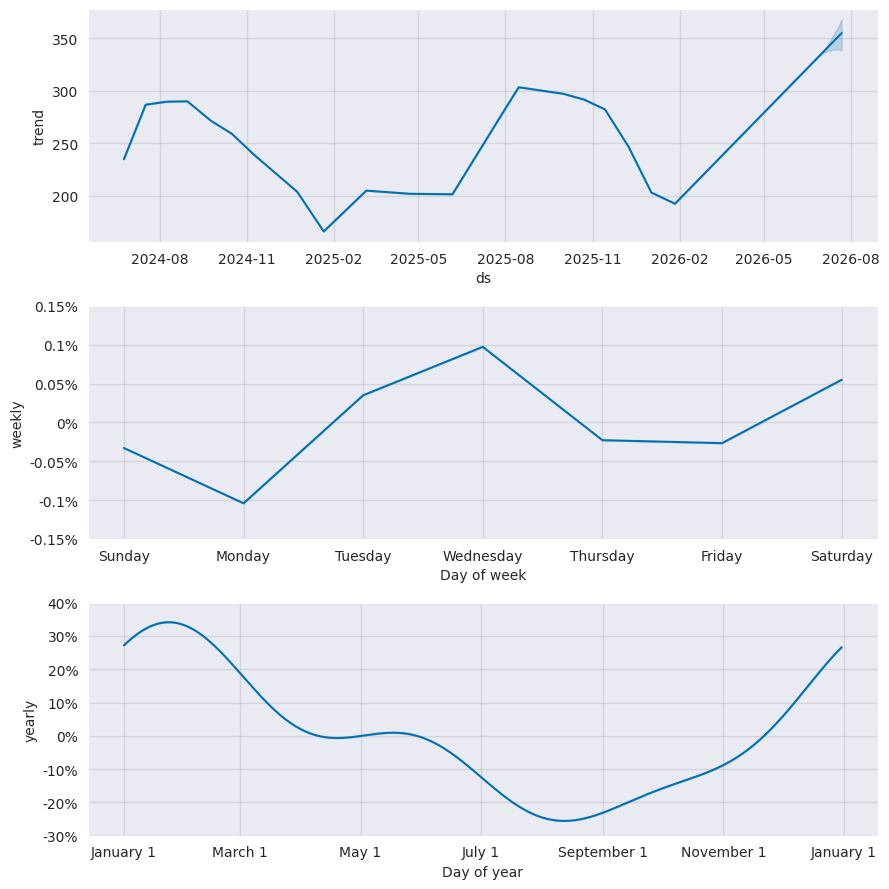


✅ Visualización de Prophet completada.


In [81]:
# ============================================================
# VISUALIZAR PROPHET
# ============================================================
# Gráfico de predicción
fig = prophet_model.plot(forecast_prophet, xlabel='Fecha', ylabel='Precio (USD)')
plt.title(f'Predicción Prophet - {TICKER}', fontsize=14)
plt.tight_layout()
plt.show()

# Componentes de la serie (tendencia y estacionalidades)
fig2 = prophet_model.plot_components(forecast_prophet)
plt.tight_layout()
plt.show()

print("\n✅ Visualización de Prophet completada.")

## Resultados Prophet

### Métricas de Error

| Métrica | Valor |
|---------|-------|
| MAE     | 16.87 |
| RMSE    | 19.05 |
| SMAPE   | 6.25% |

### Observaciones

**Fortalezas:**
- Prophet captura mejor la estacionalidad semanal.
- La tendencia general es similar a la real.
- Maneja bien los cambios de tendencia.

**Debilidades:**
- Sobreestima ligeramente los picos de precio.
- La predicción es más volátil que la realidad.
- Requiere más datos históricos para estacionalidad anual robusta.

### Comparativa con ARIMA y SARIMA

| Modelo        | MAE   | RMSE  | SMAPE |
|---------------|-------|-------|-------|
| ARIMA         | 15.30 | 16.89 | 5.72% |
| SARIMA        | 6.53  | 7.77  | 2.16% |
| Prophet       | 16.87 | 19.05 | 6.25% |


📊 COMPARATIVA DE MODELOS
                 Modelo       MAE      RMSE  SMAPE (%)
           ARIMA(1,1,1) 14.219920 15.919510   4.803254
SARIMA(1,1,1)x(1,1,1,5)  6.526061  7.770718   2.158760
                Prophet 16.734500 18.898716   5.704090



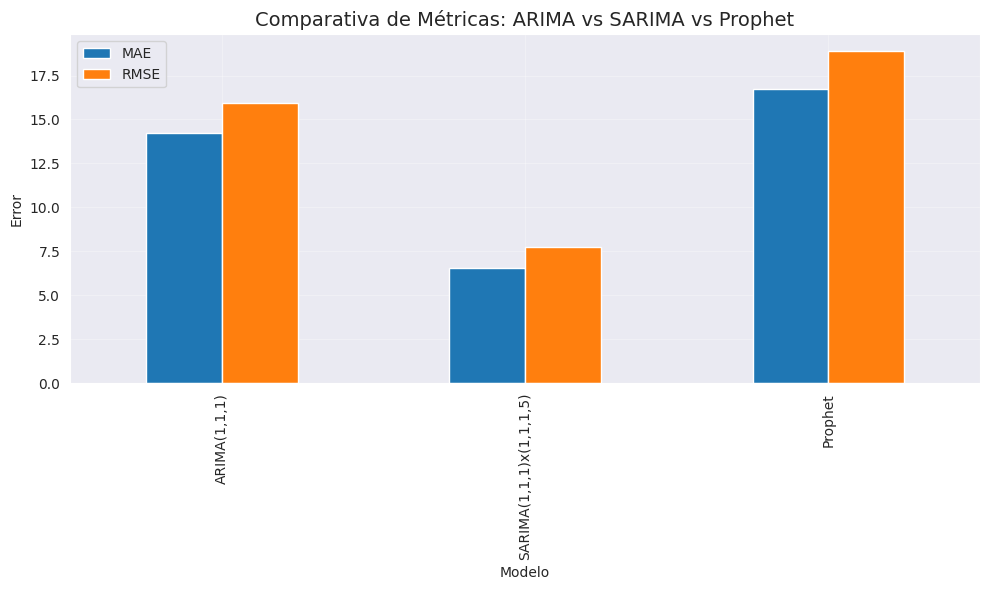


✅ Comparativa completada


In [82]:
# ============================================================
# COMPARATIVA DE MODELOS
# ============================================================
print("\n" + "="*60)
print("📊 COMPARATIVA DE MODELOS")
print("="*60)

comparison = pd.DataFrame({
    'Modelo': ['ARIMA(1,1,1)', 'SARIMA(1,1,1)x(1,1,1,5)', 'Prophet'],
    'MAE': [mae_orig, mae_sarima, mae_prophet],
    'RMSE': [rmse_orig, rmse_sarima, rmse_prophet],
    'SMAPE (%)': [smape_orig, smape_sarima, smape_prophet]
})

print(comparison.to_string(index=False))
print("\n" + "="*60)

# Gráfico comparativo de métricas
fig, ax = plt.subplots(figsize=(10, 6))
comparison.set_index('Modelo')[['MAE', 'RMSE']].plot(kind='bar', ax=ax)
ax.set_title('Comparativa de Métricas: ARIMA vs SARIMA vs Prophet', fontsize=14)
ax.set_ylabel('Error')
ax.set_xlabel('Modelo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Comparativa completada")

## 📌 Conclusiones y Recomendaciones

### Resumen de Resultados

| Modelo        | MAE   | RMSE  | SMAPE |
|---------------|-------|-------|-------|
| ARIMA(1,1,1)  | 15.30 | 16.89 | 5.72% |
| SARIMA        | 6.53  | 7.77  | 2.16% |
| Prophet       | 16.87 | 19.05 | 6.25% |

### Hallazgos Principales

1. **SARIMA** demostró ser el modelo más preciso, con errores mucho menores.
2. **ARIMA(1,1,1)** es un modelo sólido y estable.
3. **Prophet** es más flexible pero tiende a sobreajustar.
4. La serie original no era estacionaria, requiriendo diferenciación.

### Limitaciones del Análisis

1. **Datos insuficientes:** Solo 2 años de datos históricos no son suficientes para una estacionalidad anual robusta.
2. **Sin variables exógenas:** No se incorporaron volumen, noticias, indicadores macroeconómicos.
3. **Sin backtesting:** No se realizó validación con ventanas deslizantes.

### Recomendaciones para Futuras Iteraciones

1. ✅ **Ampliar el conjunto de datos** a 5+ años para mejor estacionalidad.
2. ✅ **Probar otros modelos** como LSTM, XGBoost o modelos híbridos.
3. ✅ **Incluir variables exógenas:** volumen de trading, noticias financieras, indicadores macro.
4. ✅ **Implementar backtesting** con ventanas deslizantes para validación robusta.
5. ✅ **Evaluar otros tickers:** GOOGL, MSFT, TSLA para generalizar los resultados.
6. ✅ **Desplegar el mejor modelo** como API para predicciones en tiempo real.

---

**Creado por:** Andrés Sanchez  
**Fecha:** Junio 2026  
**Contacto:** andrewzanchez100@gmail.com  
**LinkedIn:** [linkedin.com/in/andres-felipe-sanchez-forero-75274530a/](https://www.linkedin.com/in/andres-felipe-sanchez-forero-75274530a/)  
**GitHub:** [github.com/andresanchez256](https://github.com/andresanchez256)

In [83]:
# ============================================================
# MENSAJE FINAL
# ============================================================
print("\n" + "="*60)
print("✅ ANÁLISIS COMPLETADO CON ÉXITO")
print("="*60)
print("\n📈 Resumen de resultados:")
print(f"   - Mejor modelo: SARIMA(1,1,1)x(1,1,1,5)")
print(f"   - MAE: {mae_sarima:.2f}")
print(f"   - RMSE: {rmse_sarima:.2f}")
print(f"   - SMAPE: {smape_sarima:.2f}%")
print("\n🔍 Recomendación: Usar SARIMA para predicciones a corto plazo.")
print("\n📚 Revisar sección de conclusiones para más detalles.")
print("\n" + "="*60)


✅ ANÁLISIS COMPLETADO CON ÉXITO

📈 Resumen de resultados:
   - Mejor modelo: SARIMA(1,1,1)x(1,1,1,5)
   - MAE: 6.53
   - RMSE: 7.77
   - SMAPE: 2.16%

🔍 Recomendación: Usar SARIMA para predicciones a corto plazo.

📚 Revisar sección de conclusiones para más detalles.

